<a href="https://colab.research.google.com/github/heyygauravai/diabetes-risk-prediction/blob/main/diabetes-risk-prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Importing a data set from kaggle**



In [8]:
!wget  https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv

--2026-06-24 17:51:26--  https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23278 (23K) [text/plain]
Saving to: ‘pima-indians-diabetes.data.csv’

pima-indians-diabet 100%[===================>]  22.73K  --.-KB/s    in 0.001s  

2026-06-24 17:51:27 (20.0 MB/s) - ‘pima-indians-diabetes.data.csv’ saved [23278/23278]



# **Importing data handling dependencies**

In [9]:
import numpy as np
import pandas as pd

# **Importing the dataset using pandas**

In [10]:
db = pd.read_csv('/content/pima-indians-diabetes.data.csv')
db

,6,148,72,35,0,33.6,0.627,50,1
0,1,85,66,29,0,26.6,0.351,31,0
1,8,183,64,0,0,23.3,0.672,32,1
2,1,89,66,23,94,28.1,0.167,21,0
3,0,137,40,35,168,43.1,2.288,33,1
4,5,116,74,0,0,25.6,0.201,30,0
...,...,...,...,...,...,...,...,...,...
762,10,101,76,48,180,32.9,0.171,63,0
763,2,122,70,27,0,36.8,0.340,27,0
764,5,121,72,23,112,26.2,0.245,30,0
765,1,126,60,0,0,30.1,0.349,47,1


# **Adding column names**

In [11]:
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
           'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

df = pd.read_csv('/content/pima-indians-diabetes.data.csv', names=columns)
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


**Inspecting data**

In [12]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [13]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


**Checking for missing values**

In [14]:
df.isnull().sum()
#no missing values

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


**Checking for zeroes in a dataset in each column**

In [15]:
(df == 0).sum()
#zero pregnancies are quite possible
# 5 zero values of glucose are error in data as it ranges from 70 to 200mg/dl
# blood pressure cannot be 0 as it ranges from 40 to 122 mm Hg
# skin thickness cannot be 0 it ranges from 7 to 99
# insulin cannot be 0 it ranges from 14 to 846μU/mL
# bmi cannot be 0 as it ranges from 15 to 67.1

,0
Pregnancies,111
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,500


**Replacing all the zero values with median(non-zero values)**

In [16]:
col_w_0 = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

for col in col_w_0:
  # finding the median of non zero values for the current column
  non_0_median = df[df[col]>0][col].median()
  # replacing the zeroes with median we just calculated
  df[col] = df[col].replace(0, non_0_median)

**After replacing the zeroes with median calculated with non zero values:**

In [17]:
(df == 0).sum()
# no zero values

,0
Pregnancies,111
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,500


In [18]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,125,33.6,0.627,50,1
1,1,85,66,29,125,26.6,0.351,31,0
2,8,183,64,29,125,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# **Now the data has no missing values or zero values now. now we will perform EDA(exploratory data analysis)**

**Importing dependencies for Data Visualization**

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

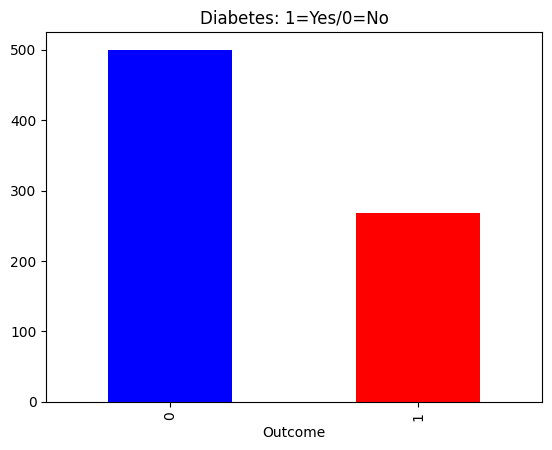

In [20]:
# how many have diabetes
df['Outcome'].value_counts().plot(kind='bar', color=['blue', 'red'])
plt.title('Diabetes: 1=Yes/0=No')
plt.show()

**Difference between Glucose levels between diabetic and non diabetic people.**

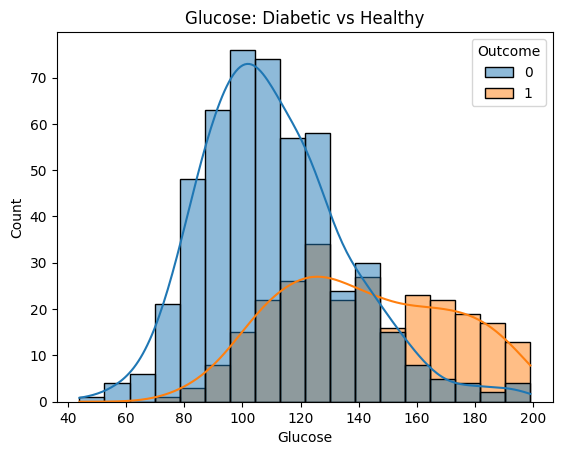

In [21]:
sns.histplot(data=df, x='Glucose', hue='Outcome', kde=True)
plt.title('Glucose: Diabetic vs Healthy')
plt.show()
# As we can see there is a direct correlation between GLucose and diabetes
# as diabetic patients have higher glucose levels.

**Scatter plot of BMI vs Glucose**

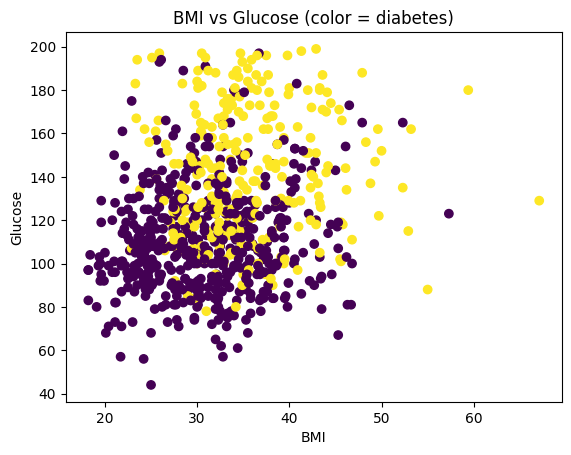

In [22]:
plt.scatter(df['BMI'], df['Glucose'], c=df['Outcome'])
plt.xlabel('BMI')
plt.ylabel('Glucose')
plt.title('BMI vs Glucose (color = diabetes)')
plt.show()

**Lets build a correlation heatmap to check the correlation between features.**

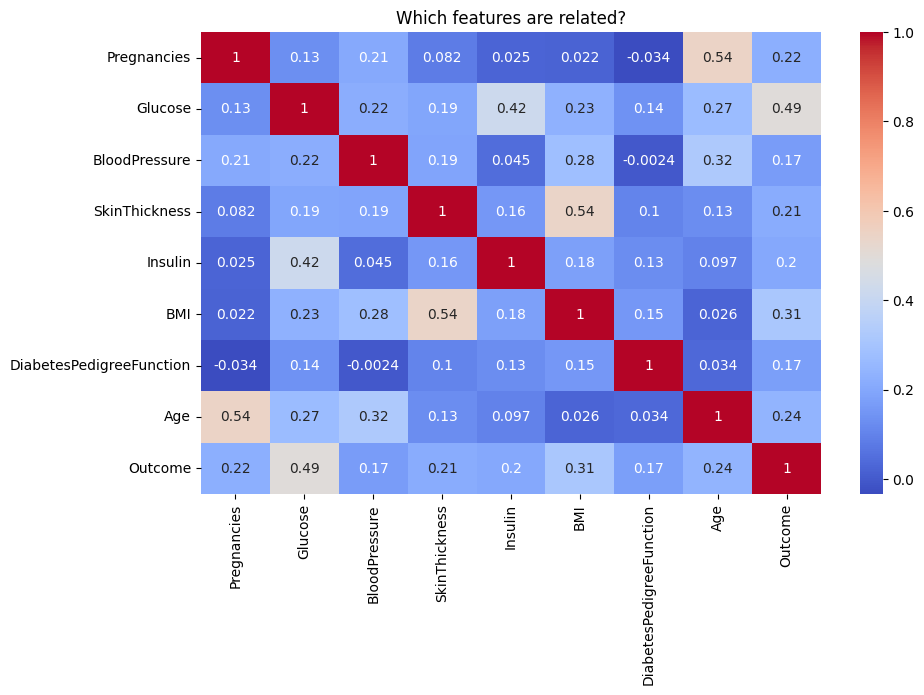

In [23]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Which features are related?')
plt.show()


# after this correlation heatmap we can clearly see that glucose is
# highly correlated to the outcome and on second and third highly
# correlated columns are BMI and Age

# **Spliting the data**

In [24]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier

In [25]:
X = X = df.drop('Outcome',axis = 1)
Y = df['Outcome']

X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

# **Using logistic regression**

In [26]:
lr = LogisticRegression()
lr.fit(X_train, Y_train)
lr_predict = lr.predict(X_test)
confusion_matrix(Y_test, lr_predict)
lr_acc_score = accuracy_score(Y_test, lr_predict)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [27]:
accuracy_score(Y_test, lr_predict)

0.7727272727272727

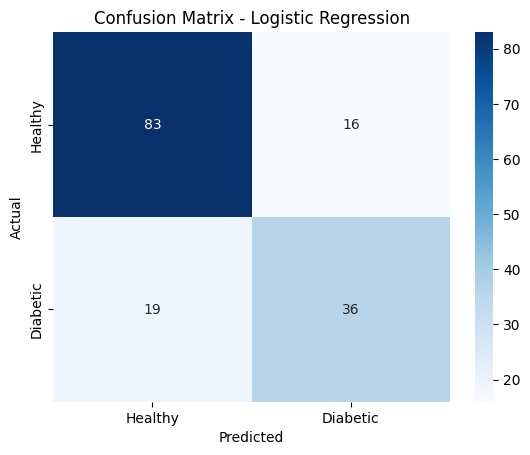

In [30]:
cm = confusion_matrix(Y_test, lr_predict)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Diabetic'],
            yticklabels=['Healthy', 'Diabetic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

**Metric Evaluation**

In [ ]:
me_lr = classification_report(Y_test, lr_predict).split('\n')
me_lr

**cross validation**

In [ ]:
cv_lr = cross_val_score(lr,X,Y,cv=10)
cv_lr.mean()

**Feature importance from Logistic Regression**

In [ ]:
lr_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': lr.coef_[0]
}).sort_values('Importance', ascending=False)

print(lr_importance.head(15))

**Raw coefficient magnitudes cannot be directly compared across features with different scales (Glucose ranges 44-199, PedigreeFunction ranges 0.08-2.42). After standardization, Glucose and BMI emerge as the strongest predictors, consistent with Random Forest and XGBoost rankings.**

# **Using randomforest**

In [ ]:
rf = RandomForestClassifier()
rf.fit(X_train, Y_train)
rf_predict = rf.predict(X_test)
accuracy_score(Y_test, rf_predict)

In [ ]:
confusion_matrix(Y_test, rf_predict)

**Metric Evaluation**

In [ ]:
me_rf = classification_report(Y_test, rf_predict).split('\n')
me_rf

**Cross Validation**

In [ ]:
cv_rf = cross_val_score(rf,X,Y,cv=10)
cv_rf.mean()


# **Feature importance from Random Forest**

In [ ]:
# Get feature importance from Random Forest
rf.fit(X_train, Y_train)

rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(rf_importance.head(15))

# Plot it
importance.head(15).plot(x='Feature', y='Importance', kind='barh', figsize=(10, 7))
plt.title('Top Features Predicting Diabetes (Updated)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# **Using XGBoost**

In [ ]:
xgb = XGBClassifier()
xgb.fit(X_train, Y_train)
xgb_predict = xgb.predict(X_test)
accuracy_score(Y_test, xgb_predict)

In [ ]:
confusion_matrix(Y_test, xgb_predict)

**Metrics evaluation**

In [ ]:
me_xgb = classification_report(Y_test, xgb_predict).split('\n')
me_xgb

**Cross Validation**

In [ ]:
cv_xgb = cross_val_score(xgb, X, Y, cv=10)
cv_xgb.mean()

**Feature importance from XGBoost**

In [ ]:
xgb_importance = pd.DataFrame({
    'Feature': X.columns,
    "Importance" : xgb.feature_importances_
}).sort_values('Importance', ascending = False)
feature_importance.head(15)

# Plot it
xgb_importance.head().plot(x='Feature', y='Importance', kind='barh')
plt.title('XGBoost Feature Importance')
plt.show()
